---
title: "Modul 6 Sains Data: *Deep Learning* dengan Keras, Regresi dan Klasifikasi Gambar"
subtitle: Functional API & Subclassing API dari Keras, Regresi & Klasifikasi Gambar dengan Neural Network"
image: https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/aggarwal_nndl_hal18.png
description: "Offline di Departemen Matematika"
date: 04/21/2026
page-navigation: true
format: html
---

Kembali ke [Sains Data](./saindat2026genap.qmd)

In [204]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# *Perceptron, revisited*: selain *Sequential API*


Di pertemuan sebelumnya, kita telah menyusun *perceptron* menggunakan Sequential API seperti berikut (ada dua cara yang ekuivalen):

In [205]:
# langsung menentukan semua layer di awal, dengan memasukkan list
model0 = keras.Sequential(
    [
        keras.layers.InputLayer(input_shape = (2,)),
        keras.layers.Dense(units = 1, activation = keras.activations.sigmoid)
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [206]:
# menambahkan layer secara berangsur-angsur
model0 = keras.Sequential()
model0.add(keras.layers.InputLayer(input_shape = (2,)))
model0.add(keras.layers.Dense(units = 1, activation = keras.activations.sigmoid))

Sequential API sebenarnya cukup terbatas: tiap *layer* harus berurutan satu sama lain, dan hubungan yang ada hanyalah antar pasangan dua *layer* yang bersebelahan.

Untuk model-model yang kita pelajari di mata kuliah Sains Data, sebenarnya Sequential API sudah cukup. Namun, kalau kalian pelajari lebih lanjut tentang *neural network* / *deep learning*, kalian akan bertemu dengan arsitektur aneh yang tidak bisa langsung disusun dengan Sequential API.

Contohnya, ada yang namanya *skip connection*, yaitu suatu *layer* terhubung dengan *layer* lain yang agak jauh darinya:

![](https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/aggarwal_nndl_hal348.png)

Sumber gambar: Aggarwal (2018) hal. 348

(*Skip connection* akan kalian temui kalau mempelajari *residual network*, yaitu arsitektur ResNet dan variasinya, yang sudah sangat di luar cakupan materi mata kuliah Sains Data.)

Untuk itu, diperlukan API selain *Sequential*, yaitu bisa dengan *Functional API* atau dengan *Subclassing API*. Agar kalian lebih mengenal Keras, kita akan mencoba membuat *perceptron* menggunakan dua API lainnya tersebut.

Kita bisa uji coba dengan dataset yang sama seperti di pertemuan sebelumnya: [titik_negatif_positif.csv](./titik_negatif_positif.csv)

In [207]:
df = pd.read_csv("./titik_negatif_positif.csv", dtype="float32")

In [208]:
inputs_df = df.drop(columns=["kelas"])
targets_df = df[["kelas"]]

In [209]:
inputs_arr = inputs_df.to_numpy()
targets_arr = targets_df.to_numpy()

## *Functional API*

Ide dari *Functional API* adalah menyusun tiap *layer* dan hubungan antar *layer* sebagai komposisi fungsi.

Untuk *Functional API*, daripada `keras.layers.InputLayer`, gunakan `keras.layers.Input`

In [210]:
m1_input = keras.layers.Input(shape = (2,))

m1_layer1_func = keras.layers.Dense(units = 1, activation = keras.activations.sigmoid)
m1_layer1_out = m1_layer1_func(m1_input) # seperti komposisi fungsi

model1 = keras.Model(inputs=m1_input, outputs=m1_layer1_out, name="model1")

In [211]:
model1.summary()

Model: "model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

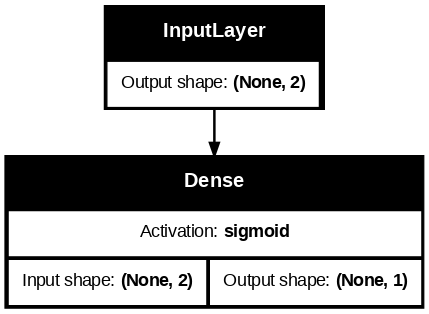

In [212]:
keras.utils.plot_model(
    model1,
    show_shapes = True,
    dpi=90,
    show_layer_activations = True,
    to_file = "keras_functional_model1.png"
)

Sisanya (*compile* lalu *fit*) sama dengan Sequential API

In [213]:
model1.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.01),
    loss = keras.losses.BinaryCrossentropy(),
    metrics = [keras.metrics.BinaryAccuracy()]
)

In [214]:
history1 = model1.fit(inputs_arr, targets_arr, epochs=100, validation_split=0.2)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - binary_accuracy: 0.9944 - loss: 0.0717 - val_binary_accuracy: 0.9875 - val_loss: 0.1239
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.9962 - loss: 0.0646 - val_binary_accuracy: 0.9900 - val_loss: 0.1077
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.9962 - loss: 0.0593 - val_binary_accuracy: 0.9950 - val_loss: 0.0956
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.9975 - loss: 0.0552 - val_binary_accuracy: 0.9975 - val_loss: 0.0863
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.9981 - loss: 0.0519 - val_binary_accuracy: 0.9975 - val_loss: 0.0789
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.9981 - loss: 0.0492 - val_binary_accuracy: 1.0000 - val_loss: 0.0730
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.9981 - loss: 0.0469 - val_binary_accuracy: 1.0000 - val_loss: 0.0680
Epoch 8/100


Kita bisa ubah *dictionary* `.history` menjadi CSV:

In [215]:
pd.DataFrame(history1.history).to_csv("./keras_functional_history1.csv", index=False)

Silakan download kalau mau menyocokkan/membandingkan dengan modul: [keras_functional_history1.csv](./keras_functional_history1.csv)

Import kembali:

In [216]:
history1_df = pd.read_csv("./keras_functional_history1.csv")

Lalu plot *loss*:

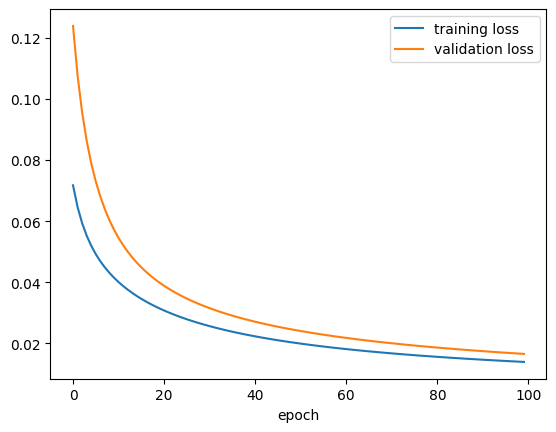

In [217]:
plt.plot(history1_df["loss"], label = "training loss")
plt.plot(history1_df["val_loss"], label = "validation loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

## *Subclassing API* (yaitu dengan OOP)

Untuk model yang lebih kompleks, mungkin komposisi fungsi akan membuat pusing, karena banyak fungsi bertebaran di mana-mana. Agar lebih rapi dan terstruktur, kita bisa gunakan *Subclassing API*, yaitu dengan OOP / *object oriented programming*.

Silakan *review* [Modul 2 Praktikum Struktur Data tentang Pengantar OOP](../../../2025/ganjil/struktur_data/modul2.ipynb) kalau perlu ;)

Dalam *Subclassing API*, model yang kita buat berupa *class* yang meng-*inherit* (atau disebut *subclassing*) dari `keras.Model` yang sudah mengimplementasikan sebagian besar *method* yang kita butuhkan.

(Bahkan, kita juga bisa buat *class* yang hanya berupa kumpulan *layer*, yang nantinya akan masuk lagi ke *class* lain. Kalian bisa pelajari lebih lanjut: <https://keras.io/guides/making_new_layers_and_models_via_subclassing/>)

Dalam model yang kita susun, hanya diperlukan:

- *constructor* `__init__` berisi minimal satu baris, yaitu `super().__init__()` dan boleh berisi baris lainnya untuk menyiapkan atribut (variabel) yang langsung bisa dibuat ketika model dibuat (sebelum mulai *training*)

- *method* `call` yang mendefinisikan bagaimana *forward pass*

- (opsional) *method* `build` yang menyiapkan atribut yang bisa dibuat di awal *training* setelah ukuran input diketahui

In [218]:
class MyPerceptron(keras.Model):
    def __init__(self, units=1):
        super().__init__()

        # banyaknya neuron di output layer
        self.units = units

    # menyiapkan parameter (weights and biases) tergantung ukuran input
    def build(self, input_shape):
        input_dim = input_shape[-1]

        # matriks W terkadang disebut kernel
        self.kernel = self.add_weight(
            shape = (input_dim, self.units),
            initializer = keras.initializers.RandomNormal(mean=0, stddev=0.05),
            trainable = True,
        )
        self.bias = self.add_weight(
            shape = (self.units,),
            initializer = keras.initializers.RandomNormal(),
            trainable = True
        )

    # forward pass
    def call(self, inputs):
        return tf.sigmoid(
            tf.matmul(inputs, self.kernel) + self.bias
        )

Kita harus membuat *instance* atau objek dari *class* ini terlebih dahulu, lalu memanggil `.build()` dulu, agar kemudian bisa melakukan misalnya `.fit()`

In [219]:
model2 = MyPerceptron()

In [220]:
model2.build(input_shape = (2,))

Sekarang kita bisa *compile*, *fit*, simpan *history*, dan plot *loss* seperti biasa...

In [221]:
model2.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.01),
    loss = keras.losses.BinaryCrossentropy(),
    metrics = [keras.metrics.BinaryAccuracy()]
)

In [222]:
history2 = model2.fit(inputs_arr, targets_arr, epochs=100, validation_split=0.2)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - binary_accuracy: 0.9031 - loss: 0.5242 - val_binary_accuracy: 0.9850 - val_loss: 0.4374
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.9969 - loss: 0.2992 - val_binary_accuracy: 0.9975 - val_loss: 0.3047
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.9981 - loss: 0.2112 - val_binary_accuracy: 0.9975 - val_loss: 0.2332
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.9987 - loss: 0.1648 - val_binary_accuracy: 0.9975 - val_loss: 0.1895
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.9987 - loss: 0.1362 - val_binary_accuracy: 1.0000 - val_loss: 0.1602
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.9987 - loss: 0.1167 - val_binary_accuracy: 1.0000 - val_loss: 0.1392
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.9987 - loss: 0.1026 - val_binary_accuracy: 1.0000 - val_loss: 0.1235
Epoch 8/100


In [223]:
pd.DataFrame(history2.history).to_csv("./keras_subclassing_history2.csv", index=False)

Silakan download kalau mau menyocokkan/membandingkan dengan modul: [keras_subclassing_history2.csv](./keras_subclassing_history2.csv)

In [224]:
history2_df = pd.read_csv("./keras_subclassing_history2.csv")

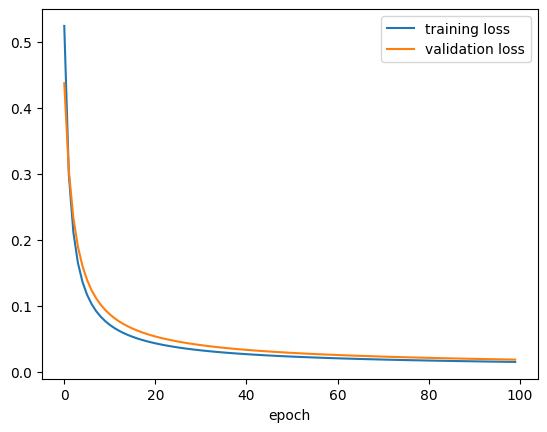

In [225]:
plt.plot(history2_df["loss"], label = "training loss")
plt.plot(history2_df["val_loss"], label = "validation loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

Sebenarnya, kalian bisa saja menggunakan *Functional API* di dalam *class*: siapkan fungsi-fungsinya di dalam *constructor* `__init__` dan gunakan di dalam `call`

In [226]:
class MyPerceptron_v2(keras.Model):
    def __init__(self, units=1):
        super().__init__()

        # banyaknya neuron di output layer
        self.units = units

        # siapkan fungsi
        self.layer1_func = keras.layers.Dense(
            units = self.units,
            activation = keras.activations.sigmoid
        )

    # forward pass
    def call(self, inputs):
        x = self.layer1_func(inputs)
        return x

# Contoh *skip connection* dengan *Functional API*

Kita lihat lagi gambar *skip connection*:

![](https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/static/aggarwal_nndl_hal348.png)

Sumber gambar: Aggarwal (2018) hal. 348

Dari gambarnya, kita bisa coba susun *neural network* nya:

In [227]:
# x
f3_input = keras.layers.Input(shape = (5,))

# weight layers
f3_layer1_func = keras.layers.Dense(units = 10, activation = keras.activations.linear)
f3_layer2_func = keras.layers.Dense(units = 5, activation = keras.activations.relu)

# F(x)
F_out = f3_layer2_func(f3_layer1_func(f3_input))

# F(x) + x
f3_layer3_out = F_out + f3_input

# membuat model akhir
model3 = keras.Model(inputs=f3_input, outputs=f3_layer3_out, name="model3")

In [228]:
model3.summary()

Model: "model3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 10)        │         60 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 5)         │         55 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 5)         │          0 │ dense_8[0][0],    │
│                     │                   │            │ input_layer_5[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 115 (460.00 B)

 Trainable params: 115 (460.00 B)

 Non-trainable params: 0 (0.00 B)

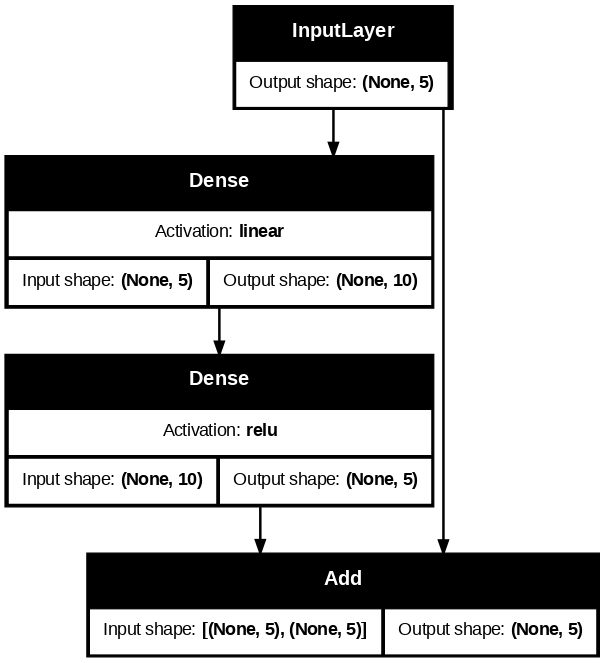

In [229]:
keras.utils.plot_model(
    model3,
    show_shapes = True,
    dpi=90,
    show_layer_activations = True,
    to_file = "keras_functional_model3.png"
)

Apabila kode *Functional API* itu disusun ke dalam *class*, kodenya bisa menjadi seperti berikut:

In [230]:
class MySkipConnection(keras.Model):
    def __init__(self, units=5):
        super().__init__()

        # banyaknya neuron di output layer
        self.units = units

        # siapkan fungsi-fungsi
        self.weight1_func = keras.layers.Dense(
            units = 10,
            activation = keras.activations.linear
        )
        self.weight2_func = keras.layers.Dense(
            units = self.units,
            activation = keras.activations.relu
        )

    # forward pass
    def call(self, inputs):
        F_x = self.weight2_func(self.weight1_func(inputs))
        x = inputs
        hasil = F_x + x
        return hasil

# *Neural Network* untuk Regresi

Ingat kembali, untuk regresi,

- banyaknya *neuron* di *input layer* sesuai banyaknya fitur/variabel prediktor

- banyaknya *neuron* di *output layer* sesuai banyaknya fitur/variabel target (biasanya hanya satu), dan fungsi aktivasi yang digunakan adalah fungsi aktivasi linier/identitas

- fungsi aktivasi untuk semua *hidden layer* biasanya ReLU

Kita akan coba lagi dataset "California Housing Prices" (housing.csv) yang sudah kita gunakan di [Modul 2](./modul2.ipynb) tentang regresi, yang bisa didownload dari salah satu sumber berikut:

* [Direct link (langsung dari GitHub Pages ini)](https://raw.githubusercontent.com/aslab-math-ui/asset/main/sains_data/datasets/housing.csv)

* Kaggle: <https://www.kaggle.com/datasets/camnugent/california-housing-prices>

Mari kita lihat isinya

In [231]:
housing_df = pd.read_csv("./housing.csv")

In [232]:
housing_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


seperti biasa, pastikan tidak ada NaN atau nilai yang kosong. Jika ada, lakukan imputasi atau buang saja

In [233]:
housing_df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [295]:
#buang baris yang mengandung nan
housing_df = housing_df.dropna().reset_index(drop=True)
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Kalau mau, kalian bisa melakukan *encoding* data kategorik `ocean_proximity` seperti di [Modul 2](./modul2.ipynb). Tapi kali ini kita hapus/*drop* saja

In [235]:
housing_df_reg = housing_df.drop(columns=["ocean_proximity"])

In [236]:
housing_df_reg

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


Ingat bahwa variabel target (variabel yang ingin kita prediksi) adalah `median_house_value`. Kita pisah dulu antara variabel prediktor (X atau inputs) dan variabel target (y atau target)

In [237]:
housing_X_df_reg = housing_df_reg.drop(columns=["median_house_value"])
housing_y_df_reg = housing_df_reg[["median_house_value"]]

Lalu kita ubah jadi numpy array agar bisa diolah Keras

In [254]:
housing_X_arr_reg = housing_X_df_reg.to_numpy()
housing_y_arr_reg = housing_y_df_reg.to_numpy()

In [239]:
print(housing_X_arr_reg.shape)
print(housing_y_arr_reg.shape)

(20433, 8)
(20433, 1)


Train test split, standarisasi:

In [240]:
from sklearn.model_selection import train_test_split

In [241]:
X_train, X_test, y_train, y_test = train_test_split(
    housing_X_arr_reg, housing_y_arr_reg, test_size=0.1, random_state=42
)

In [242]:
from sklearn.preprocessing import StandardScaler

In [243]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Data target juga relatif sangat besar, sehingga sebaiknya kita *scaling* juga:

In [244]:
print(f'y min: {y_train.min()}')
print(f'y max: {y_train.max()}')

y min: 14999.0
y max: 500001.0


In [245]:
y_train /= 100000
y_test /= 100000

In [246]:
print(f'y min: {y_train.min()}')
print(f'y max: {y_train.max()}')

y min: 0.14999
y max: 5.00001


Sekarang kita bisa susun modelnya

In [247]:
keras.backend.clear_session()

In [255]:
model4 = keras.Sequential(
    [
        keras.layers.InputLayer(shape = (housing_X_arr_reg.shape[1:])),
        keras.layers.Dense(units = 15, activation = keras.activations.relu),
        keras.layers.Dense(units = 30, activation = keras.activations.relu),
        keras.layers.Dense(units = 1, activation = keras.activations.linear)
    ]
)

In [256]:
model4.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 15)             │           135 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646 (2.52 KB)

 Trainable params: 646 (2.52 KB)

 Non-trainable params: 0 (0.00 B)

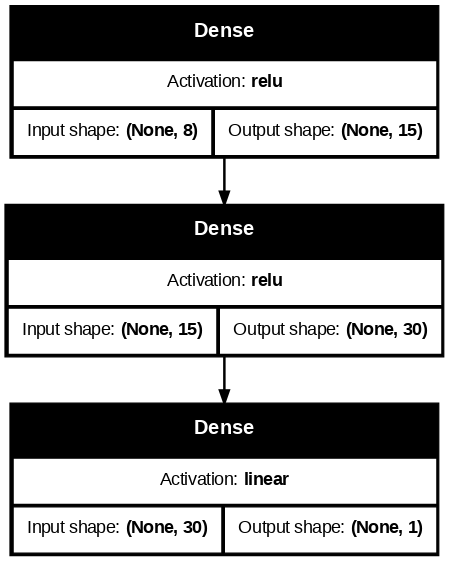

In [257]:
keras.utils.plot_model(
    model4,
    show_shapes = True,
    dpi=90,
    show_layer_activations = True,
    to_file = "keras_sequential_model4.png"
)

Selanjutnya, kita tentukan *hyperparameter*: *optimizer*, *loss function*, dan *accuracy*.

Ingat kembali, untuk regresi, *loss function* yang biasa digunakan adalah MSE *(Mean Squared Error)*

In [258]:
early_stop = keras.callbacks.EarlyStopping(
    patience=5, monitor='val_loss', restore_best_weights=True, verbose=1
)

In [259]:
model4.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = keras.losses.MeanSquaredError(),
    metrics = [keras.metrics.Accuracy()]
)

In [260]:
history4 = model4.fit(X_train, y_train, epochs=100, validation_split=1/9)

Epoch 1/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0000e+00 - loss: 0.9410 - val_accuracy: 0.0000e+00 - val_loss: 0.5404
Epoch 2/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.4472 - val_accuracy: 0.0000e+00 - val_loss: 0.4264
Epoch 3/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.3959 - val_accuracy: 0.0000e+00 - val_loss: 0.3970
Epoch 4/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.3737 - val_accuracy: 0.0000e+00 - val_loss: 0.3860
Epoch 5/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.3589 - val_accuracy: 0.0000e+00 - val_loss: 0.3868
Epoch 6/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.3494 - val_accuracy: 0.0000e+00 - val_loss: 0.3665
Epoch 7/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.3412 - val_accuracy: 0.0000e+00 - val_loss: 0.3648
Epoch 8/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 

In [261]:
pd.DataFrame(history4.history).to_csv("./keras_sequential_history4.csv", index=False)

Silakan download kalau mau menyocokkan/membandingkan dengan modul: [keras_sequential_history4.csv](./keras_sequential_history4.csv)

In [262]:
history4_df = pd.read_csv("./keras_sequential_history4.csv")

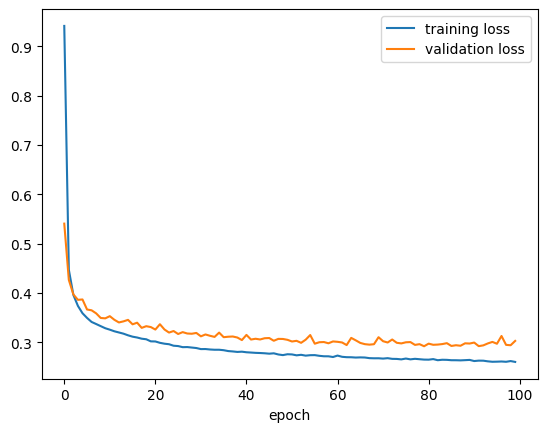

In [263]:
plt.plot(history4_df["loss"], label = "training loss")
plt.plot(history4_df["val_loss"], label = "validation loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


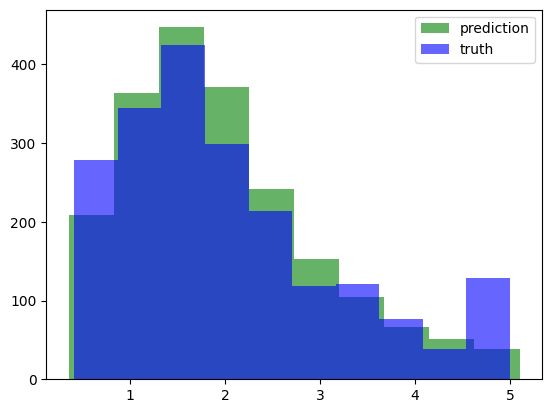

In [264]:
y_pred = model4.predict(X_test)

plt.hist(y_pred, color='green', alpha=.6)
plt.hist(y_test, color='blue', alpha=.6)
plt.legend(['prediction', 'truth'], loc='upper right')
plt.show()

# Klasifikasi

Sekarang, kita akan coba lagi dataset "California Housing Prices" (housing.csv), tetapi target kita kali ini adalah kategori `ocean_proximity`

In [292]:
housing_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [296]:
#melihat ada brp value berbeda pada feature/kolom ocean_proximity
housing_df["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

Karena terdapat 5 kelas, maka neural network yang akan kita buat akan memiliki 5 neuron pada output layer

Berbeda dengan Decision Tree, Neural network memerlukan variabel target dalam bentuk numerik juga. Kita lakukan *One-hot Encoding* terlebih dahulu seperti yang sudah kita lakukan di [Modul 1](./modul1.ipynb)

In [297]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
hasil_onehot = encoder.fit_transform(housing_df[["ocean_proximity"]])

In [298]:
print(encoder.categories_)

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


In [299]:
kolom_encoding = list(encoder.categories_[0])
onehot_array = hasil_onehot.toarray()
print(onehot_array)

[[0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 ...
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]


In [300]:
onehot_df = pd.DataFrame(onehot_array, columns=kolom_encoding)

In [301]:
housing_df_encoded = pd.concat([housing_df, onehot_df], axis=1)
housing_df_encoded = housing_df_encoded.drop(["ocean_proximity"], axis=1)

In [302]:
housing_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   <1H OCEAN           20433 non-null  float64
 10  INLAND              20433 non-null  float64
 11  ISLAND              20433 non-null  float64
 12  NEAR BAY            20433 non-null  float64
 13  NEAR OCEAN          20433 non-null  float64
dtypes: float64(14)
memory usage: 2.2 MB


Karena semua fitur sudah berupa numerik, maka kita lakukan preprocess data yang serupa seperti sebelumnya

In [303]:
housing_X_df = housing_df_encoded.drop(columns=["<1H OCEAN", "INLAND", "ISLAND", "NEAR BAY", "NEAR OCEAN"])
housing_y_df = housing_df_encoded[["<1H OCEAN", "INLAND", "ISLAND", "NEAR BAY", "NEAR OCEAN"]]

In [304]:
housing_X_arr = housing_X_df.to_numpy()
housing_y_arr = housing_y_df.to_numpy()

In [305]:
print(housing_X_arr.shape)
print(housing_y_arr.shape)

(20433, 9)
(20433, 5)


Train test split, standarisasi:

In [306]:
X_train, X_test, y_train, y_test = train_test_split(
    housing_X_arr, housing_y_arr, test_size=0.1, random_state=42
)

In [307]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Sekarang kita susun model untuk klasfikasi

In [308]:
keras.backend.clear_session()

In [309]:
model5 = keras.Sequential(
    [
        keras.layers.InputLayer(shape = (housing_X_arr.shape[1:])),
        keras.layers.Dense(units = 15, activation = keras.activations.relu),
        keras.layers.Dense(units = 30, activation = keras.activations.relu),
        keras.layers.Dense(units = 5, activation = keras.activations.softmax)
    ]
)

In [310]:
model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 15)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           155 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

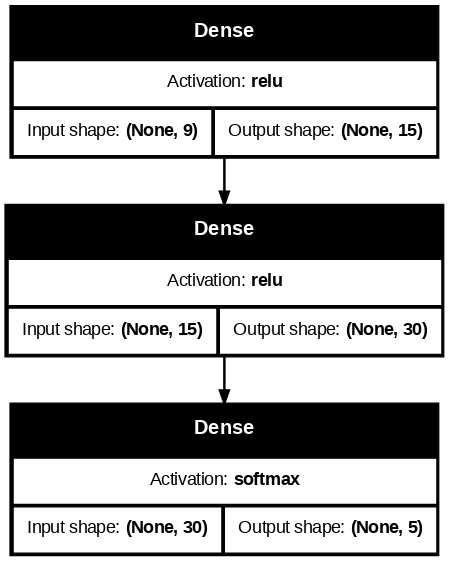

In [311]:
keras.utils.plot_model(
    model5,
    show_shapes = True,
    dpi=90,
    show_layer_activations = True,
    to_file = "keras_sequential_model4.png"
)

Selanjutnya, kita tentukan *hyperparameter*: *optimizer*, *loss function*, dan *accuracy*.

Ingat bahwa untuk klasifikasi, *loss function* yang biasa digunakan adalah *cross entropy*

In [312]:
model5.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = keras.losses.CategoricalCrossentropy(),
    metrics = [keras.metrics.Accuracy()]
)

In [313]:
history5 = model5.fit(X_train, y_train, epochs=100, validation_split=1/9)

Epoch 1/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0000e+00 - loss: 0.9007 - val_accuracy: 0.0000e+00 - val_loss: 0.6915
Epoch 2/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 2.4472e-05 - loss: 0.6306 - val_accuracy: 0.0000e+00 - val_loss: 0.6054
Epoch 3/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 4.6497e-04 - loss: 0.5285 - val_accuracy: 5.8708e-04 - val_loss: 0.4941
Epoch 4/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0021 - loss: 0.4311 - val_accuracy: 0.0023 - val_loss: 0.4081
Epoch 5/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0033 - loss: 0.3732 - val_accuracy: 0.0043 - val_loss: 0.3677
Epoch 6/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0059 - loss: 0.3414 - val_accuracy: 0.0061 - val_loss: 0.3460
Epoch 7/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0087 - loss: 0.3229 - val_accuracy: 0.0099 - val_loss: 0.3291
Epoch 8/100
511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0112 -

In [314]:
pd.DataFrame(history5.history).to_csv("./keras_sequential_history5.csv", index=False)

In [315]:
history5_df = pd.read_csv("./keras_sequential_history5.csv")

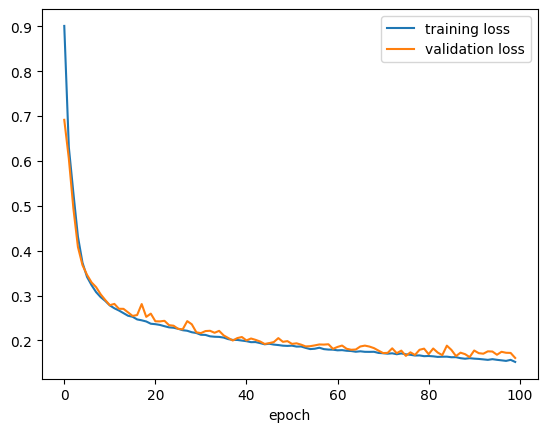

In [316]:
plt.plot(history5_df["loss"], label = "training loss")
plt.plot(history5_df["val_loss"], label = "validation loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

confusion matrix

In [317]:
yhat = model5.predict(X_test)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [324]:
yhat

array([[4.34084155e-04, 3.89699584e-13, 7.53203116e-04, 1.45267978e-33,
        9.98812675e-01],
       [1.09212195e-09, 1.00000000e+00, 0.00000000e+00, 1.26548324e-16,
        4.20022330e-17],
       [9.96228874e-01, 1.26364001e-04, 7.68042974e-15, 1.66372224e-24,
        3.64468084e-03],
       ...,
       [9.96213377e-01, 1.46981212e-03, 1.12137505e-18, 2.31433720e-25,
        2.31667515e-03],
       [9.96018708e-01, 3.66451126e-03, 5.44608271e-17, 2.97511475e-24,
        3.16747261e-04],
       [9.95582521e-01, 1.10517816e-04, 1.75360377e-13, 2.16995364e-22,
        4.30701533e-03]], dtype=float32)

Berbeda dengan pada modul 3, karena kita melakukan One-hot Encoding maka hasil yang kita peroleh pada *output layer* berupa vektor probabilitas. Kita akan ambil probabilitas terbesar nya sebagai kelas akhirnya

In [339]:
#visualisasi confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  """
  This function prints and plots the confusion matrix.
  Normalization can be applied by setting `normalize=True`.
  """
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  print(cm)

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')

# argument max
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(yhat, axis=1)
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])
print(cm)

[[861   9   0   0  31]
 [ 32 632   0   0   1]
 [  0   0   0   0   0]
 [  4   2   0 214   0]
 [ 34   0   0  11 213]]


Confusion matrix, without normalization
[[861   9   0   0  31]
 [ 32 632   0   0   1]
 [  0   0   0   0   0]
 [  4   2   0 214   0]
 [ 34   0   0  11 213]]


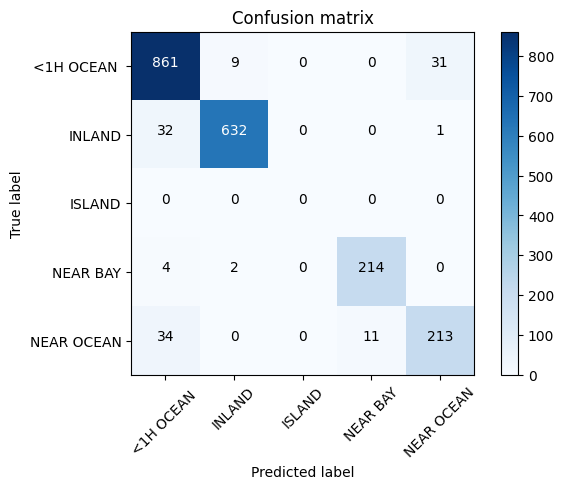

In [336]:
from sklearn.metrics import confusion_matrix

#confusion matrix
cnf_matrix = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])

plt.figure()
plot_confusion_matrix(cnf_matrix,classes=['<1H OCEAN ', 'INLAND', "ISLAND", "NEAR BAY", "NEAR OCEAN"],normalize = False, title='Confusion matrix')

In [345]:
housing_df["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
NEAR OCEAN,2628
NEAR BAY,2270
ISLAND,5


Terlihat bahwa data sangat tidak seimbang, ini sebabnya model kita tidak pernah menebak ISLAND